# 5T OTA : BW as Spec
Only constraint is Cload, gm_id and L are set by param
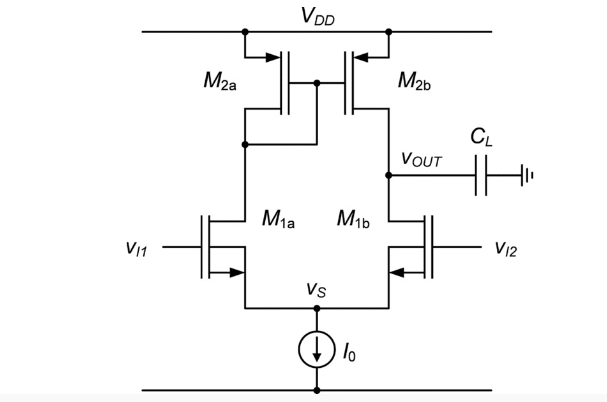 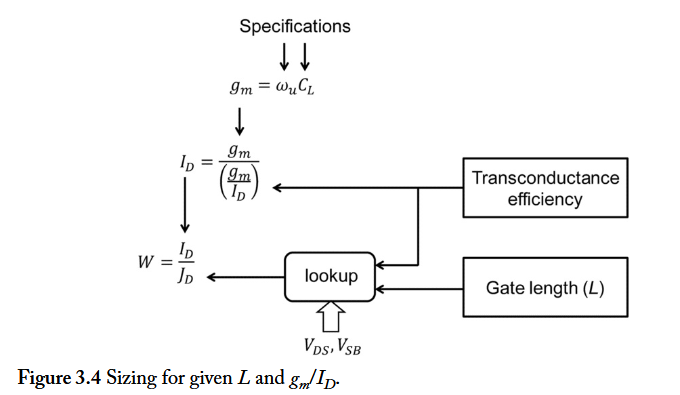

## Import libs

In [1]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('../../lookup_table/035/pmos4.mat')
nmos4 = lk('../../lookup_table/035/nmos4.mat')
import sys; sys.path.append('../..')
import adri

## Set specifications / Param

In [2]:
spec = {'fu' : 100e3,
        'cload' : 10e-12,
        'vdd' : 2.7,
        'vic' : 1.35
        }
param = {
        'l_mos' : 2,
         'gm_id1' : 15,
         'gm_id2' : 10
         }

## Design with self loading loop

In [3]:
m1,m2, perf = adri.ota_5T_L_gmid(nmos4, pmos4, spec, param)
adri.print_design_summary(spec,perf,m1,m2)

## Use Plot gain/Ibias versus L to choose L

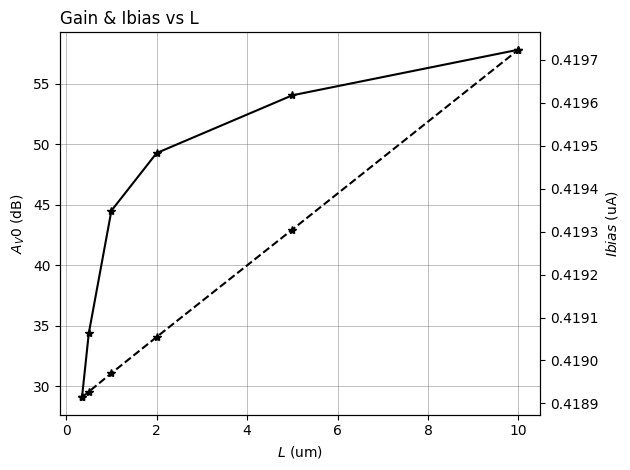

In [4]:
#Short version + exemple sweep L pour voir gain et ibias
AV_test = []
IBIAS_test = []
for l_test in nmos4['L']:
    param['l_mos'] = l_test
    m1,m2, perf = adri.ota_5T_L_gmid(nmos4, pmos4, spec, param)
    AV_test.append(perf['AV0'])
    IBIAS_test.append(perf['ibias']*1e6)

l_test = nmos4['L']

fig, ax1 = plt.subplots()
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax1.plot(l_test, AV_test, color='black', linewidth=1.5, marker='*')
plt.xlabel('$L$ (um)')
plt.ylabel(r'$A_V0$ (dB)')
ax2 = ax1.twinx()
ax2.plot(l_test, IBIAS_test,linestyle='--', color='black', linewidth=1.5, marker='*')
plt.ylabel(r'$Ibias$ (uA)')
#ax2.ticklabel_format(axis='y', style='sci', scilimits=(-4, -4), useMathText=True)
ax2.set_title('Gain & Ibias vs L', loc='left', fontsize=12, fontweight='normal')
plt.tight_layout()
plt.show()


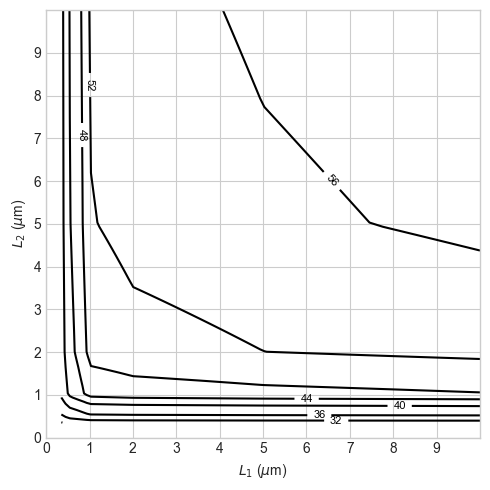

In [5]:
Lsweep = np.linspace(0.35, 10, 100)
gmID1 = 15
gmID2 = gmID1
gdsID1 = nmos4.look_up('GDS_ID', GM_ID=gmID1, L=Lsweep)
gdsID2 = pmos4.look_up('GDS_ID', GM_ID=gmID2, L=Lsweep)

L0 = np.zeros((len(Lsweep), len(Lsweep)))
for j in range(len(Lsweep)):
    L0[j,:] = gmID1 / (gdsID1 + gdsID2[j])
L0 = 20*np.log10(L0)

plt.style.use("seaborn-v0_8-whitegrid")
# Plotting
fig, ax = plt.subplots(figsize=(5,5))
C = ax.contour(Lsweep, Lsweep, L0, colors='k', levels = 8 )
ax.clabel(C, fmt='%d', fontsize=8)
ax.set_xticks(np.arange(0, 10, 1))
ax.set_yticks(np.arange(0, 10, 1))
ax.set_xlabel(r'$L_{1}$ ($\mu$m)')
ax.set_ylabel(r'$L_{2}$ ($\mu$m)')
plt.tight_layout()
plt.show()